In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

<span style='color:green'> 

# Data Preprocessing
</span>


# 1.Handle Missing Values

In [5]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [6]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

<span style='color:green'> 

# Feature Engineering
</span>


In [7]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

In [8]:
#Age
df["Age"] = 2026 - df["Year_Birth"]


In [9]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [10]:
#Customer Joining Date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customer Tenure days"] = (reference_date - df["Dt_Customer"]).dt.days

In [11]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer Tenure days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [12]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer Tenure days'],
      dtype='object')

In [13]:
# Spending

df["Total_Spending"] = df["MntWines"] +  df["MntFruits"] +  df["MntMeatProducts"]+ df["MntFishProducts"]+ df["MntSweetProducts"]+ df["MntGoldProds"]

In [14]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer Tenure days,Total_Spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,422


In [15]:
#Children
df["Total_Children"] = df["Kidhome"] +  df["Teenhome"]

In [16]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer Tenure days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [17]:
#Education

df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic":"Undergraduate",
    "2n Cycle": "Undergraduate",
    "Graduation" : "Graduate",
    "Master":"PostGraduate",
    "PhD": "PostGraduate"


})



#Undergraduate,Graduate,PostGraduate

In [18]:
df["Education"].value_counts()

Education
Graduate         1127
PostGraduate      856
Undergraduate     257
Name: count, dtype: int64

In [19]:
# Marital Status

df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [20]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married":"Partner",
    "Together": "Partner",
    "Single" : "Alone",
    "Divorced":"Alone",
    "Widow": "Alone",
    "Absurd":"Alone",
    "YOLO":"Alone"


})

In [21]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

# <span style='color:green'>Drop Columns</span>

In [22]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer Tenure days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,PostGraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [23]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer Tenure days', 'Total_Spending',
       'Total_Children', 'Living_With'],
      dtype='object')

In [24]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts","MntGoldProds"]


cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns = cols_to_drop)

In [25]:
df_cleaned.shape

(2240, 15)

In [26]:
df.shape

(2240, 27)

In [27]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer Tenure days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


<span style='color:green'>
    
 # Outliers
</span>

In [28]:
cols = ["Income","Recency","Response","Age","Total_Spending","Total_Children"]

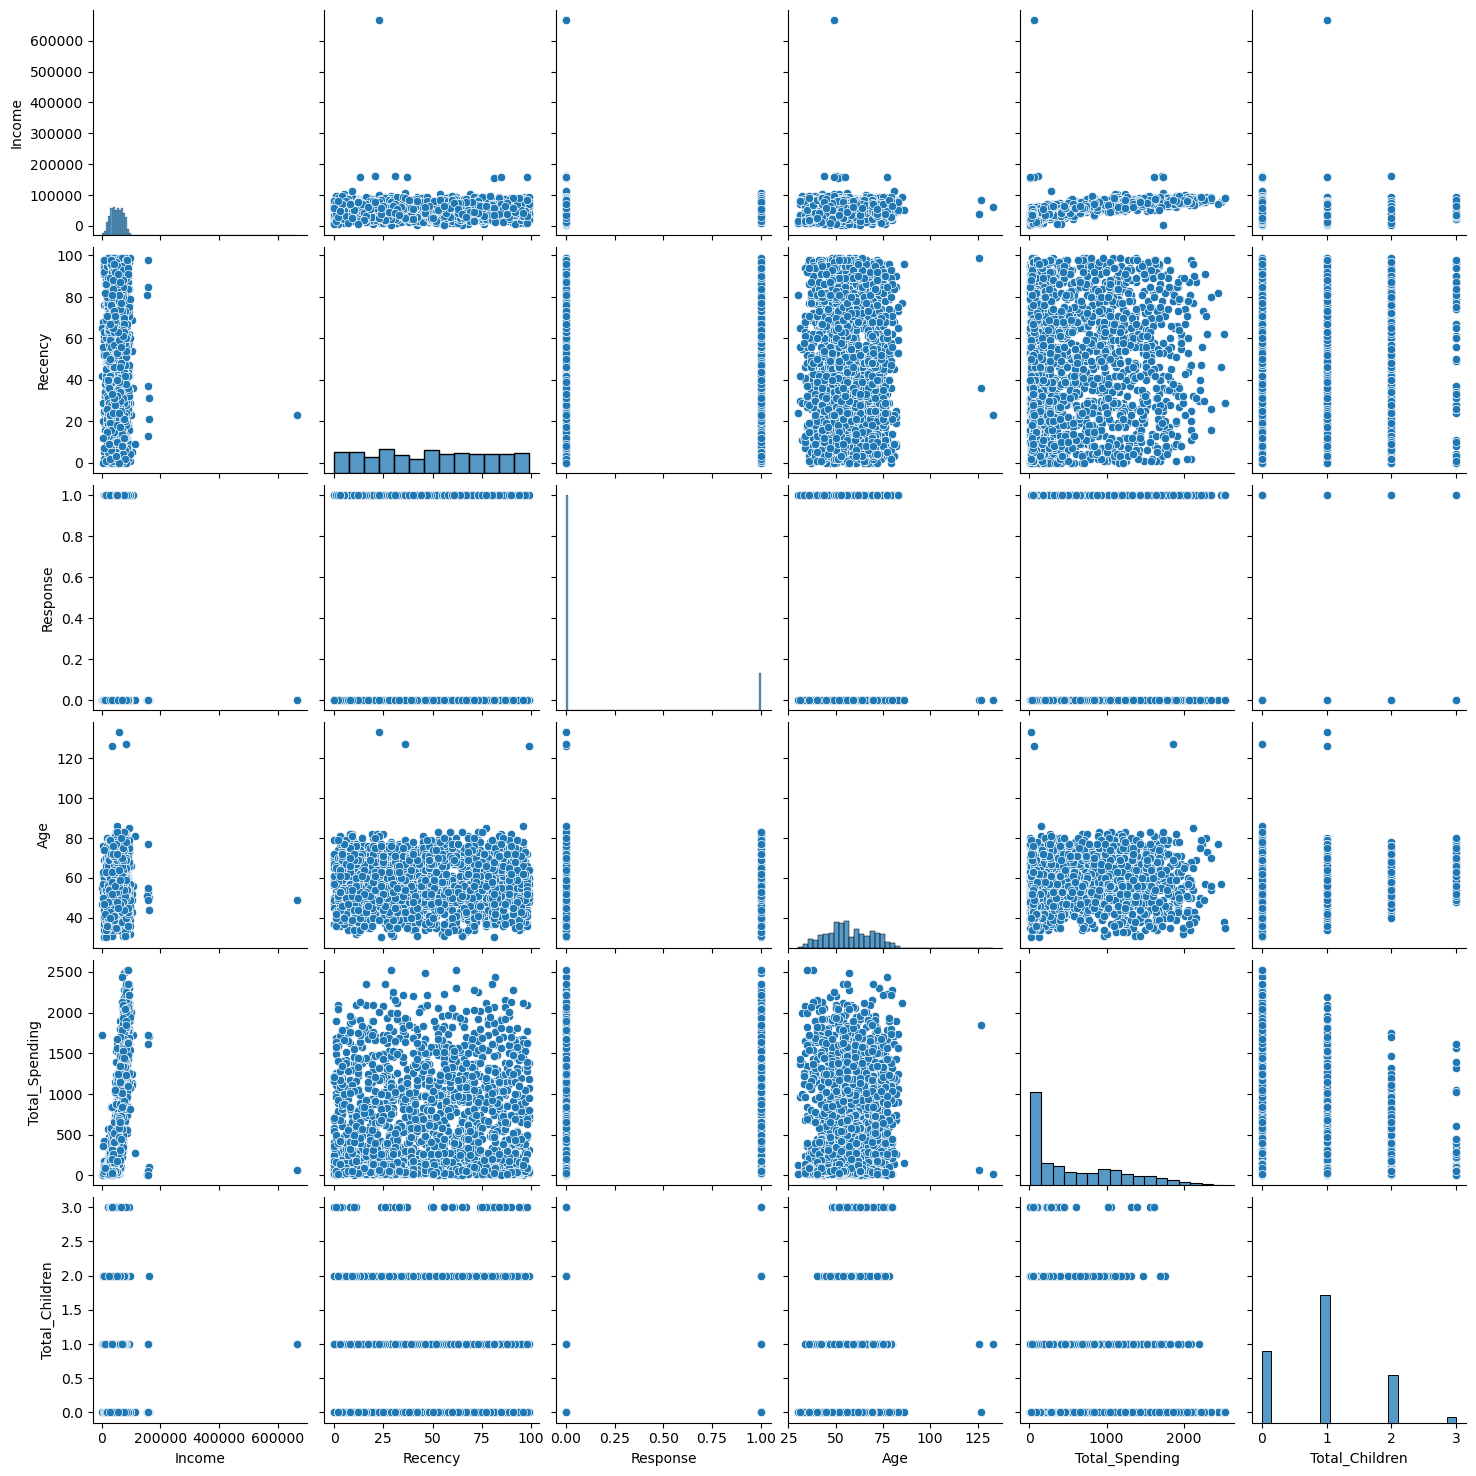

In [29]:
# relative plots of some features pair plots
sns.pairplot(df_cleaned[cols])

In [30]:
#Remove outliers

print("data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)]
df_cleaned = df_cleaned[(df_cleaned["Income"] < 600_000)]

print("data size without  outliers:", len(df_cleaned))

data size with outliers: 2240
data size without  outliers: 2236


<span style='color:green'>
              
# Heatmap 
</span>

In [31]:
corr  = df_cleaned.corr(numeric_only=True)

<Axes: >

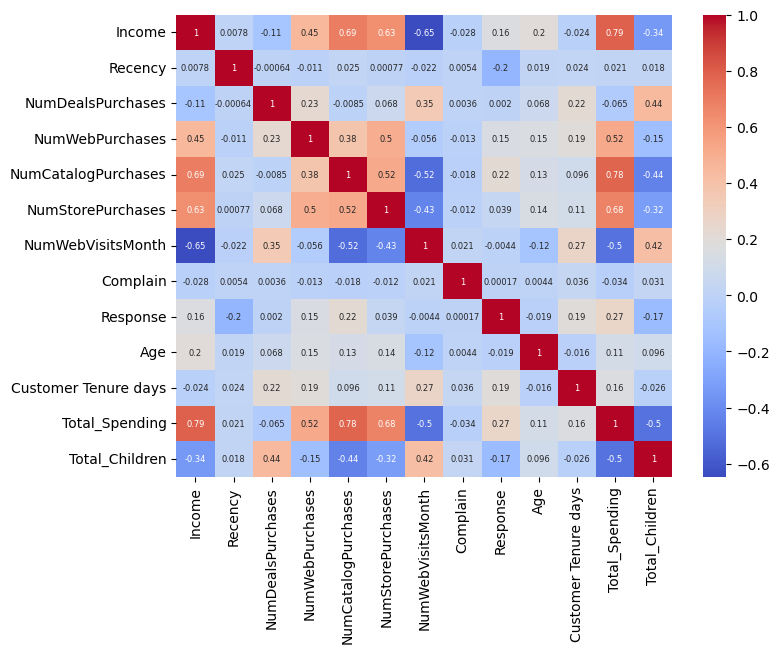

In [32]:
plt.figure(figsize = (8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws ={"size":6},
    cmap = "coolwarm"
)
    
    

In [33]:
df_cleaned.shape

(2236, 15)

In [34]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer Tenure days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


<span style='color:green'>

# Encoding
</span>

In [35]:
from sklearn.preprocessing import OneHotEncoder

In [36]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [37]:
enc_df = pd.DataFrame(enc_cols.toarray(),columns = ohe.get_feature_names_out(cat_cols),index = df_cleaned.index)

In [38]:
enc_df.head()

,Education_Graduate,Education_PostGraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [39]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [40]:
df_encoded.shape

(2236, 18)

In [41]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer Tenure days,Total_Spending,Total_Children,Education_Graduate,Education_PostGraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


<span style='color:green'>

# Scaling
</span>

In [42]:
from sklearn.preprocessing import StandardScaler


In [43]:
X = df_encoded

In [44]:
scaler = StandardScaler()

In [45]:
X_scaled = scaler.fit_transform(X)

<span style='color:green'>

# Visualize
</span>

In [46]:
X_scaled.shape

(2236, 18)

In [47]:
#2D

from sklearn.decomposition import PCA

In [48]:
pca = PCA(n_components = 3)

x_pca = pca.fit_transform(X_scaled)

In [49]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

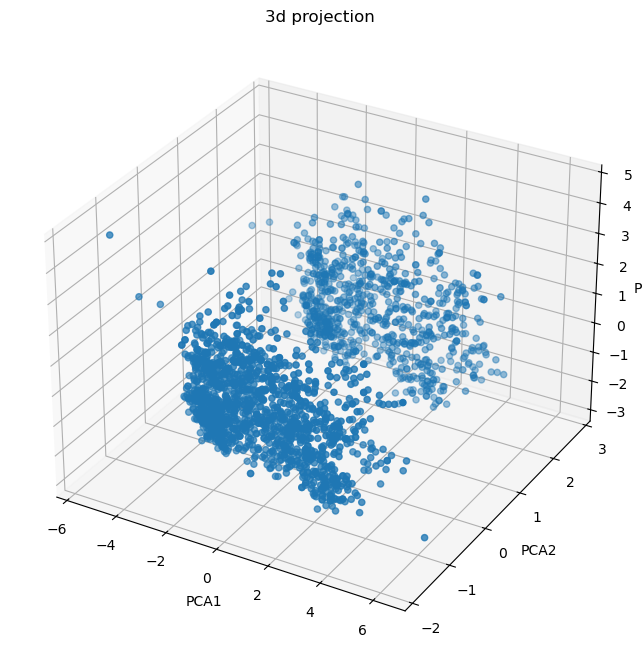

In [50]:
#plot 
fig = plt.figure(figsize = (8,10))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

In [51]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

# Analyze K vaue
# 1.Elbow Method

In [52]:
from sklearn.cluster import KMeans
from kneed import KneeLocator


wcss = []
for k in range(1,11):
    Kmeans = KMeans(n_clusters=k,random_state=42)
    Kmeans.fit_predict(x_pca)
    wcss.append(Kmeans.inertia_)

In [53]:
knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k = knee.elbow

In [54]:
print("best k =",optimal_k)

best k = 4


Text(0, 0.5, 'wcss')

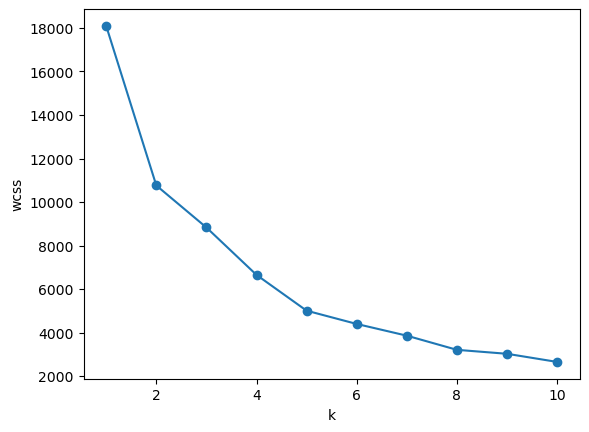

In [55]:
#plot

plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("k")
plt.ylabel("wcss")

# 2.Silhouette Score

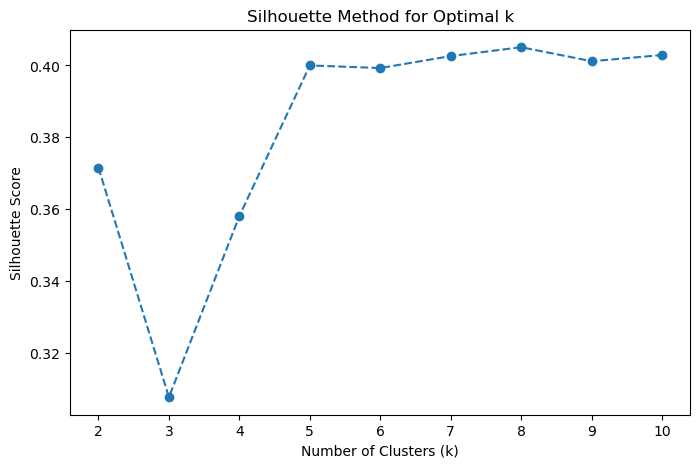

In [56]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    # Initialize with lowercase 'k'
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    
    # Use the same variable name 'kmeans' here
    labels = kmeans.fit_predict(x_pca) 
    
    score = silhouette_score(x_pca, labels)
    scores.append(score)

# Plotting the results
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), scores, marker='o', linestyle='--')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method for Optimal k")
plt.show()

Text(0, 0.5, 'ss')

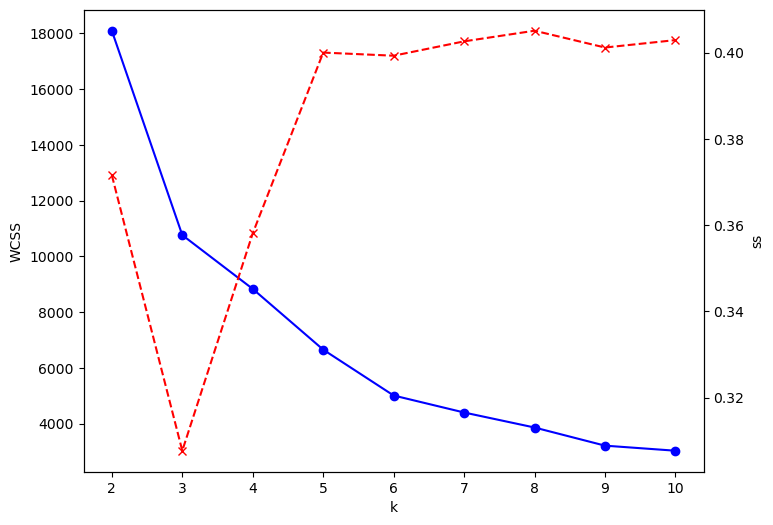

In [57]:
#combined plot 

k_range = range(2,11)

fig,ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("k")
ax1.set_ylabel("WCSS")


ax2 = ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",color="red",linestyle="--")
ax2.set_ylabel("ss")


<span style='color:green'>

# Clustering
</span>

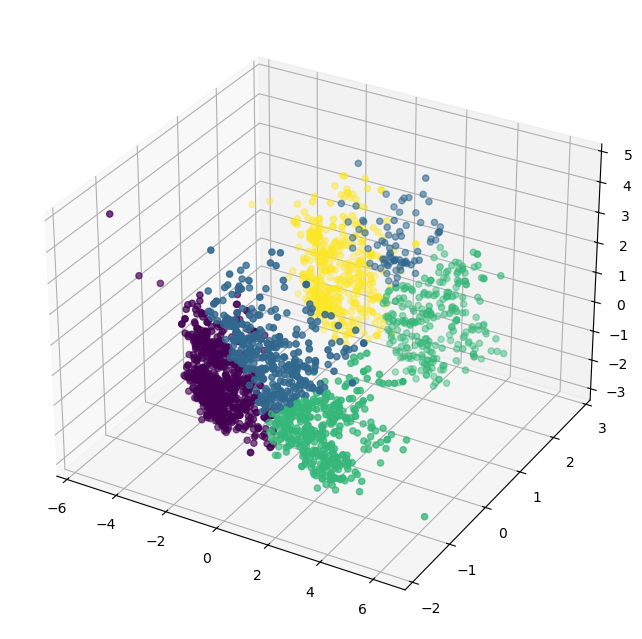

In [58]:
# K_means

Kmeans = KMeans(n_clusters=4,random_state=42)
labels_kmeans = Kmeans.fit_predict(x_pca)

#plot 
fig = plt.figure(figsize = (8,10))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_kmeans)

In [59]:
#Agglomerative Clustering

from sklearn.cluster import AgglomerativeClustering


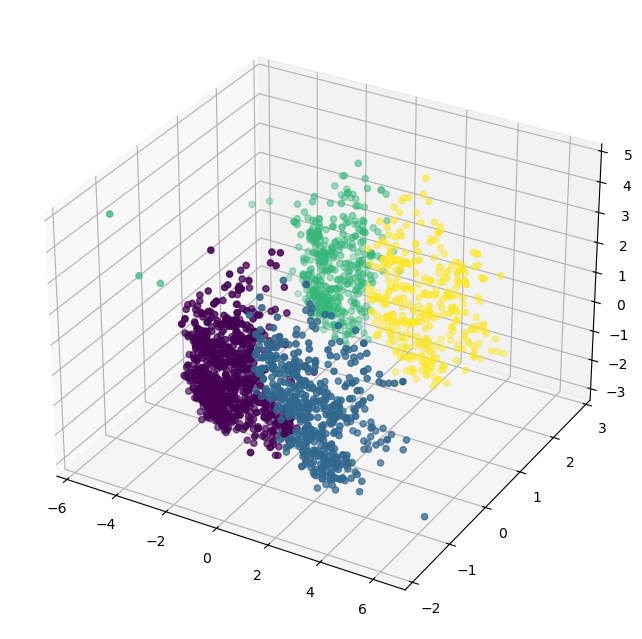

In [63]:
agg_clf = AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg = agg_clf.fit_predict(x_pca)

#plot 
fig = plt.figure(figsize = (8,10))

ax = fig.add_subplot(111,projection="3d")


ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_agg)


<span style='color:green'>

# Characterization of clusters
</span>

In [79]:

#df_cleaned.drop("labels",axis=1)
X["cluster"] = labels_agg

In [80]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer Tenure days,Total_Spending,Total_Children,Living_With,labels,cluster
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,3,3
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,2,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner,1,1
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner,0,0
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner,0,0


<Axes: xlabel='cluster', ylabel='count'>

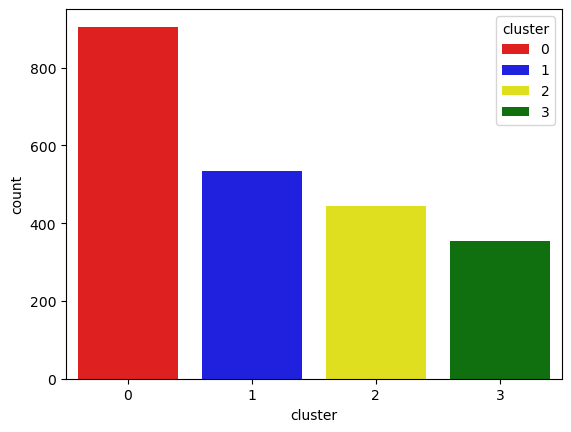

In [81]:
pal = ["red","blue","yellow","green"]

sns.countplot(x=X["cluster"],palette=pal,hue=X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

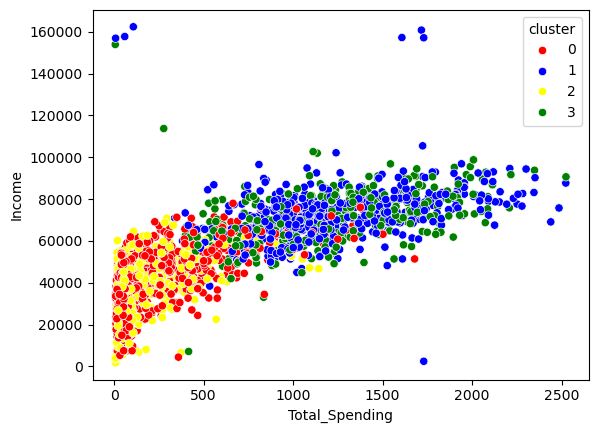

In [82]:
# Income and Spending Patterns

sns.scatterplot(x=X["Total_Spending"] , y = X["Income"], hue = X["cluster"],palette=pal)

In [83]:
# Clustering Summary


cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer Tenure days  Total_Spending  \
cluster         